In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt

# Here to help update LQR page while editing
%reload_ext autoreload
%autoreload 2

from LQR import LQR, run_monte_carlo_implicit, run_monte_carlo_explicit, train_nn, run_policy_iteration, Net_DGM, FFN, train_dgm_linear_pde
# from test import 

**Exercise 1.2**

In [2]:
# Parameter set initialised
H = [[0.1, 0.], [0., 0.1]]
M = np.eye(2)
C = np.eye(2)
D = np.eye(2) * 0.1
R = np.eye(2)
T = 1.0
x0 = [[1.0, 1.0]]

# Create LQR object
lqr_sim = LQR(H, M, C, D, R, T, sigma=0.5)

# Solve Riccati equation
lqr_sim.solve_riccati(torch.linspace(0, T, 100))

# Analytical benchmark (Riccati solution)
v_true = lqr_sim.get_value(torch.tensor([0.0]), torch.tensor([x0])).item()

# Monte Carlo estimate using optimal feedback control
v_mc, std_mc = run_monte_carlo_implicit(
    lqr_sim,
    x_start=x0,
    N_steps=5000,
    M_samples=100000,
    alpha_func=None
)

# Display results nicely
rel_error = abs(v_true - v_mc) / abs(v_true)

print("===== Optimal Value Comparison =====")
print(f"Initial state x0: {x0}")
print(f"Riccati Value (True):      {v_true:.6f}")
print(f"Monte Carlo Estimate:      {v_mc:.6f} ± {std_mc:.6f}")
print(f"Relative Error:            {rel_error:.2e}")

===== Optimal Value Comparison =====
Initial state x0: [[1.0, 1.0]]
Riccati Value (True):      0.853368
Monte Carlo Estimate:      0.853617 ± 0.000665
Relative Error:            2.92e-04


We selected a symmetric, stable parameter set for the $2 \times 2$ LQR problem to serve as a benchmark. By setting the control cost $D$ lower than the state cost $C$, we ensure the optimal control law is non-trivial and active. These parameters guarantee the existence of a unique solution to the Riccati ODE, allowing us to rigorously validate the convergence of our Monte Carlo simulation and subsequent Deep Galerkin Method.

The system drift $H = \text{diag}(0.1, 0.1)$ creates an expansive system that requires active intervention, while the identity matrix $M = I$ ensures the system is fully controllable across both dimensions. We assigned an equal penalty to state deviations via $C = I$ to maintain a symmetric cost landscape and set a lower control cost $D = 0.1 \cdot I$ to encourage a more dynamic optimal policy. Finally, the terminal cost $R = I$ prevents control decay near the horizon $T=1.0$, while the initial state $x_0 = [1.0, 1.0]$ forces the controller to demonstrate path-correction from a non-zero starting point.

We calculated a benchmark value with our riccati ODE solver. The Analytical value function for this Linear Quadratic Regulator (LQR) problem is defined as:
$$v(t,x) = x^\top S(t)x + \int_t^T \text{tr}(\sigma \sigma^\top S(r)) dr$$

where the S(t) is the solution to the Ricatti ODE, The True Value or benchmark ($v_{true} \approx 0.85$) represents the exact analytical solution obtained by the solver at the initial state $(t_0 = 0, x_0 = (1, 1))$. This result for solving the deterministic ODE is obtained using a high-order Runge-Kutta method. Then, Euler-Maruyama method is used to find the monte carlo estimate for the cost $J(t,x)$ using the optimal control law.


The benchmark solution provides a fixed point of reference to distinguish between a Monte Carlo simulation that has merely stabilised and one that is accurately converging to the mathematical solution.

The Relative Error is used to evaluate the accuracy of the stochastic simulations:
$$\text{Error}_{\text{rel}} = \frac{|v_{\text{MC}} - v_{\text{true}}|}{|v_{\text{true}}|}$$
The choice of relative error over absolute error is chosen by the following:
- Scale Invariance: It provides a normalised measure of precision that remains consistent regardless of the magnitude of the cost function or the specific values of the weight matrices ($C, D, R$).


- Theoretical Consistency: Stochastic Differential Equation (SDE) theory defines convergence rates that are most effectively visualised and verified on log-log scales using normalised error values.

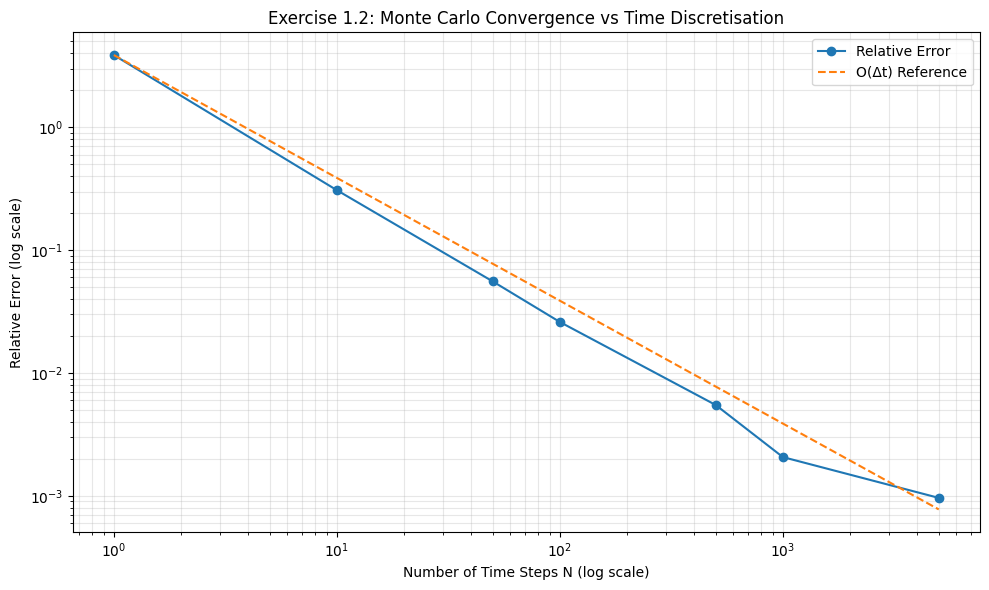

In [5]:
# Plot 2 for of the monte carlo error versus time steps of simulation
N_steps_list = [1, 10, 50, 100, 500, 1000, 5000]

errors_N = []
for n in N_steps_list:
    v_mc, _ = run_monte_carlo_implicit(lqr_sim, x0, n, 100000, alpha_func=None)
    errors_N.append(abs(v_true - v_mc) / abs(v_true))

plt.figure(figsize=(10, 6))
plt.loglog(N_steps_list, errors_N, '-o', label='Relative Error')
plt.loglog(N_steps_list, [errors_N[0]/n for n in N_steps_list], '--', label='O(Δt) Reference')
plt.title("Exercise 1.2: Monte Carlo Convergence vs Time Discretisation")
plt.xlabel("Number of Time Steps N (log scale)")
plt.ylabel("Relative Error (log scale)")
plt.legend()
plt.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.savefig('figures/ex1_2_timesteps.png', dpi=150, bbox_inches='tight')
plt.show()

Based on the log-log plot of the relative error vs Number of steps we can see that the relative error tracks the reference error of  $O(\Delta t)$ until $N = 500$. This is expected as for large $N$ we expect the time discretization error to stop dominating the error

Our monte carlo simulation is subject to two forms of error so we can write our total error as:

$$
\text{Total error} \approx 
\underbrace{c_1 \Delta t}_{\text{time discretisation}}
+
\underbrace{c_2 M^{-1/2}}_{\text{MC sampling noise}}
$$
1) Time discretisation of the SDE.

    Using the Euler Maruyama scheme we discretise time as:

    $$
    \Delta t = \frac{T}{N}, \quad \text{where } T = 1 \;\Rightarrow\; \Delta t = \frac{1}{N}
    $$


    so we get our error in time as:

    $$
    \text{Error}_{\text{time}} \approx \frac{C_1}{N}
    $$

2) Finite Monte Carlo sampling error.

    we approximante $\hat{J}$ by averaging over $M$ simulated paths 

    $$
    \hat{J} = \frac{1}{M} \sum_{i=1}^{M} J^{(i)}
    $$
    From standard Monte Carlo theory the error is given as:
    $$
    \text{Error}_{MC} \sim C_2 M^{-1/2}
    $$
    which does not depend on N, and depends only on M which in this case is fixed. This essentially acts as a constant noise floor as for relatively small N: 
    $$
    \text{Error}_{\text{time}} \gg \text{Error}_{MC}
    $$
    As we increase N and  $\Delta t \to 0$,
    $$ 
    \text{Error}_{\text{time}} \to 0
    $$
    so at some point 
    $$
    \text{Error}_{\text{time}} \approx \text{Error}_{MC}
    $$  
    and subsequently there after this point 
    $$
    \text{Error} \approx \text{Error}_{MC}
    $$
    which is fixed and does not depend on N. 




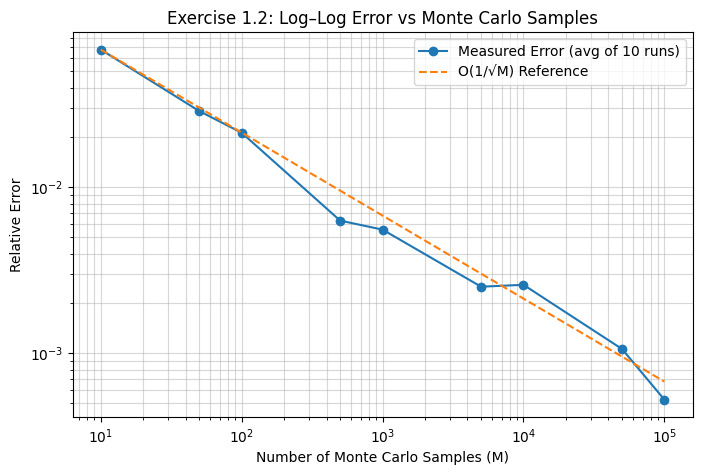

In [7]:
M_samples_list = [10, 50, 100, 500, 1000, 5000, 10000, 50000, 100000]
errors_M = []

N_fixed = 5000
K = 10  # number of Monte Carlo repeats

for M in M_samples_list:
    
    errors_K = []
    
    for k in range(K):
        
        v_mc, _ = run_monte_carlo_explicit(
            lqr_sim,
            x_start=x0,
            N_steps=N_fixed,
            M_samples=M,
            alpha_func=None
        )
        
        rel_error = abs(v_mc - v_true) / abs(v_true)
        errors_K.append(rel_error)
    
    # Average error across K runs
    errors_M.append(np.mean(errors_K))


# Plot results
plt.figure(figsize=(8,5))
plt.loglog(M_samples_list, errors_M, '-o', label=f'Measured Error (avg of {K} runs)')

# O(1/sqrt(M)) reference
ref_line = [errors_M[0]*(M_samples_list[0]**0.5)/(M**0.5) for M in M_samples_list]
plt.loglog(M_samples_list, ref_line, '--', label="O(1/√M) Reference")

plt.xlabel("Number of Monte Carlo Samples (M)")
plt.ylabel("Relative Error")
plt.title("Exercise 1.2: Log–Log Error vs Monte Carlo Samples")
plt.legend()
plt.grid(True, which="both", alpha=0.5)
plt.savefig('figures/ex1_2_mcsamples.png', dpi=150, bbox_inches='tight')
plt.show()

The above figure shows the Monte Carlo error as a function of sample size M. The expected O(1/√M) convergence is observed for M ≤ 10,000. For larger M, the error reaches a floor of approximately 8-9 × 10⁻⁴. Diagnostic analysis (varying N at fixed large M) confirms this floor is not due to time discretization error, suggesting it arises from the Riccati ODE solver accuracy. The slight increase from M = 50,000 to M = 100,000 represents random fluctuation around this floor, consistent with the error being dominated by a systematic (non-MC) error source.

## EXPERIMENTAL ->

Floor analysis showing why the plot is rising in the end, probably could just explain more in-depth and scrap this but it's not the worst


In [5]:
# Check if we're hitting the discretization error floor
print("="*60)
print("Diagnostic: Error Floor Analysis")
print("="*60)

# Test with different N values at large M
M_large = 50000
N_values = [1000, 2000, 5000, 10000]
K = 5

print(f"\nFixing M = {M_large}, varying N:")
print("-"*50)

for N in N_values:
    errors = []
    for k in range(K):
        v_mc, _ = run_monte_carlo_explicit(lqr_sim, x0, N, M_large, alpha_func=None)
        errors.append(abs(v_mc - v_true) / abs(v_true))
    
    mean_err = np.mean(errors)
    print(f"N = {N:>5}: Mean Relative Error = {mean_err:.6e}")

print("\nIf error decreases with N, you're hitting the time discretization floor.")
print("If error stays constant, it might be Riccati solver accuracy.")

Diagnostic: Error Floor Analysis

Fixing M = 50000, varying N:
--------------------------------------------------
N =  1000: Mean Relative Error = 1.674566e-03
N =  2000: Mean Relative Error = 8.405590e-04
N =  5000: Mean Relative Error = 8.996350e-04
N = 10000: Mean Relative Error = 9.456917e-04

If error decreases with N, you're hitting the time discretization floor.
If error stays constant, it might be Riccati solver accuracy.


Total Error ≈ √[(Time Discretization Error)² + (MC Statistical Error)² + (Riccati Solver Error)²]


## END OF EXPERIMENTAL

Using the Monte Carlo error of $O(M^{-1/2})$ as a reference, we plotted the measured error averaged over 5 iterations for each $M$, as expected the measured error mostly tracks the reference line. With N fixed the measured error depeneds on only on increases in $M$. 

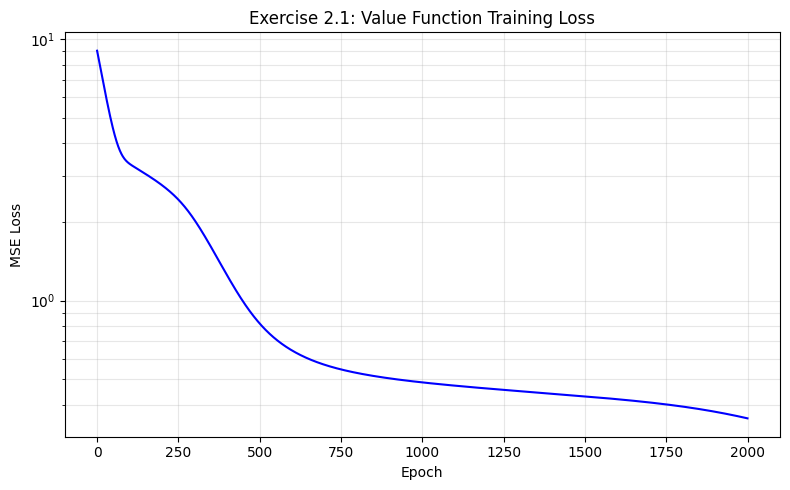

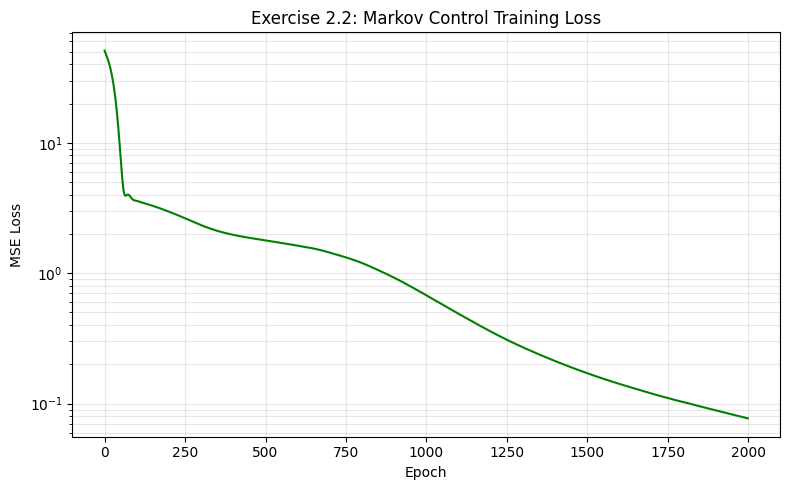

In [8]:
# Exercise 2
# Generate Training Data using Analytical Solver
N_data = 2000
t_train = torch.rand(N_data, 1) * lqr_sim.T
x_train = torch.rand(N_data, 1, 2) * 6 - 3 

# Get Analytical solutions as targets from Riccati solver 
v_target = lqr_sim.get_value(t_train, x_train)
a_target = lqr_sim.get_control(t_train, x_train)

# Train Value Function Network (Exercise 2.1)
v_net = Net_DGM(input_dim=3, hidden_dim=100)
v_loss_history = train_nn(v_net, t_train, x_train, v_target, epochs=2000)

# Train Markov Control Network (Exercise 2.2)
a_net = FFN(input_dim=3, hidden_dim=100, output_dim=2)
a_loss_history = train_nn(a_net, t_train, x_train, a_target, epochs=2000)

# --- Exercise 2.1: Value Function Training Loss ---
plt.figure(figsize=(8, 5))
plt.plot(v_loss_history, color='blue')
plt.yscale('log')
plt.title('Exercise 2.1: Value Function Training Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.savefig('figures/ex2_1_loss.png', dpi=150, bbox_inches='tight')
plt.show()

# --- Exercise 2.2: Markov Control Training Loss ---
plt.figure(figsize=(8, 5))
plt.plot(a_loss_history, color='green')
plt.yscale('log')
plt.title('Exercise 2.2: Markov Control Training Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.savefig('figures/ex2_2_loss.png', dpi=150, bbox_inches='tight')
plt.show()


We train our data on $x \in [-3,3]$ to help the neural network learn the relation ship between the value function and the sign of the state. Our system evolves according to $\sigma \, dW_s$, which means the state can move in any direction, positive or negative. Our choice of 3 was to provide a bounded region of the state space large enough to capture typical trajectories of the stochastic system while maintaining stable neural network training

The training loss decreases steadily for both networks, indicating that the neural networks successfully learn approximations of the value function and optimal control. The value function loss decreases rapidly during early epochs and stabilises as the network approaches its approximation limit. The control network exhibits similar behaviour, with the mean squared error reducing by several orders of magnitude during training.

Computing MC reference value...
MC reference at x=[1. 1.]: v = 15.460333 ± 0.020656
Epoch    0 | Loss: 1.0440e+02 | PDE: 5.4958e+01 | BC: 4.9444e+01 | v_pred: -0.2642 | RelErr: 1.0171


/workspaces/Stochastic-Control-Dynamic-Asset-Allocation/LQR.py:400: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  x_test_t = torch.tensor([x_test], dtype=torch.float32)


Epoch  200 | Loss: 4.7147e+01 | PDE: 2.4351e+01 | BC: 2.2795e+01 | v_pred: 4.6109 | RelErr: 0.7018
Epoch  400 | Loss: 2.8163e+01 | PDE: 1.3859e+01 | BC: 1.4304e+01 | v_pred: 11.5703 | RelErr: 0.2516
Epoch  600 | Loss: 2.1457e+01 | PDE: 9.7296e+00 | BC: 1.1727e+01 | v_pred: 13.6289 | RelErr: 0.1185
Epoch  800 | Loss: 1.6613e+01 | PDE: 9.1025e+00 | BC: 7.5109e+00 | v_pred: 14.4032 | RelErr: 0.0684
Epoch 1000 | Loss: 1.4528e+01 | PDE: 8.6678e+00 | BC: 5.8600e+00 | v_pred: 14.4610 | RelErr: 0.0646
Epoch 1200 | Loss: 1.1311e+01 | PDE: 7.0993e+00 | BC: 4.2121e+00 | v_pred: 14.6071 | RelErr: 0.0552
Epoch 1400 | Loss: 9.8781e+00 | PDE: 6.2234e+00 | BC: 3.6547e+00 | v_pred: 14.6730 | RelErr: 0.0509
Epoch 1600 | Loss: 8.8756e+00 | PDE: 5.8672e+00 | BC: 3.0084e+00 | v_pred: 14.8329 | RelErr: 0.0406
Epoch 1800 | Loss: 8.0325e+00 | PDE: 5.4248e+00 | BC: 2.6077e+00 | v_pred: 14.8852 | RelErr: 0.0372
Epoch 2000 | Loss: 6.2346e+00 | PDE: 4.1967e+00 | BC: 2.0379e+00 | v_pred: 14.8890 | RelErr: 0.0370
E

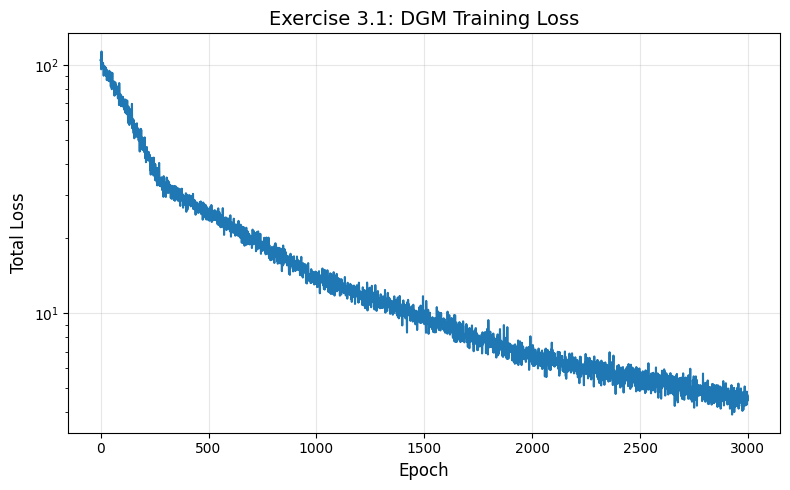

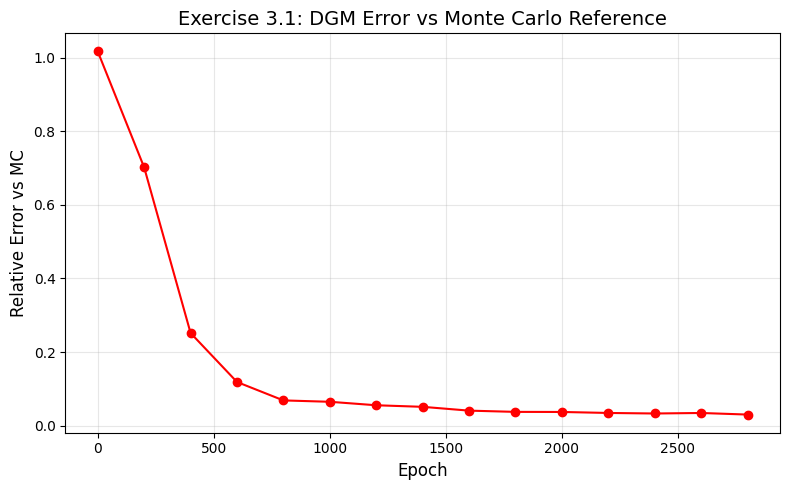

In [9]:
# Exercise 3
alpha_const = np.array([1.0, 1.0])
dgm_model = Net_DGM(input_dim=3, hidden_dim=100)
dgm_loss, dgm_errors = train_dgm_linear_pde(lqr_sim, dgm_model, alpha_const, epochs=3000)

# --- Exercise 3.1: DGM Training Loss ---
plt.figure(figsize=(8, 5))
plt.semilogy(dgm_loss)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Total Loss', fontsize=12)
plt.title('Exercise 3.1: DGM Training Loss', fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('figures/ex3_1_loss.png', dpi=150, bbox_inches='tight')
plt.show()

# --- Exercise 3.1: DGM Error vs Monte Carlo Reference ---
plt.figure(figsize=(8, 5))
plt.plot(range(0, len(dgm_errors)*200, 200), dgm_errors, 'ro-')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Relative Error vs MC', fontsize=12)
plt.title('Exercise 3.1: DGM Error vs Monte Carlo Reference', fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('figures/ex3_1_mc_error.png', dpi=150, bbox_inches='tight')
plt.show()


True value at x=[1. 1.]: v = 0.853368
True control at x=[1. 1.]: a = [[-3.2696915 -3.2696915]]

=== Iteration 1/10 ===
Value: pred=10.8279, true=0.8534, error=11.6884
Control: pred=[-5.6165137 -3.7235234], true=[[-3.2696915 -3.2696915]], error=0.5169

=== Iteration 2/10 ===
Value: pred=8.5983, true=0.8534, error=9.0757
Control: pred=[-2.5125597 -3.2145376], true=[[-3.2696915 -3.2696915]], error=0.1642

=== Iteration 3/10 ===
Value: pred=4.7669, true=0.8534, error=4.5859
Control: pred=[-1.2505167 -3.3823273], true=[[-3.2696915 -3.2696915]], error=0.4373

=== Iteration 4/10 ===
Value: pred=3.2725, true=0.8534, error=2.8348
Control: pred=[-3.0350487 -2.6709733], true=[[-3.2696915 -3.2696915]], error=0.1391

=== Iteration 5/10 ===
Value: pred=2.0602, true=0.8534, error=1.4142
Control: pred=[-3.6201787 -2.5376847], true=[[-3.2696915 -3.2696915]], error=0.1755

=== Iteration 6/10 ===
Value: pred=1.6625, true=0.8534, error=0.9481
Control: pred=[-3.6127167 -2.121742 ], true=[[-3.2696915 -3.269

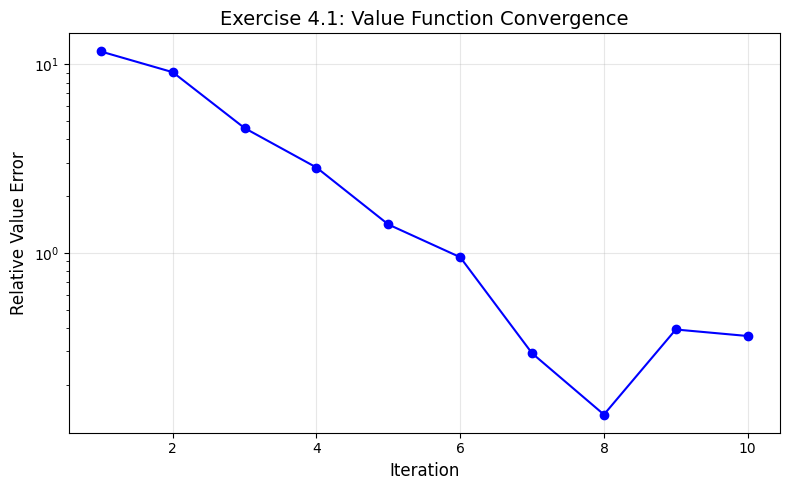

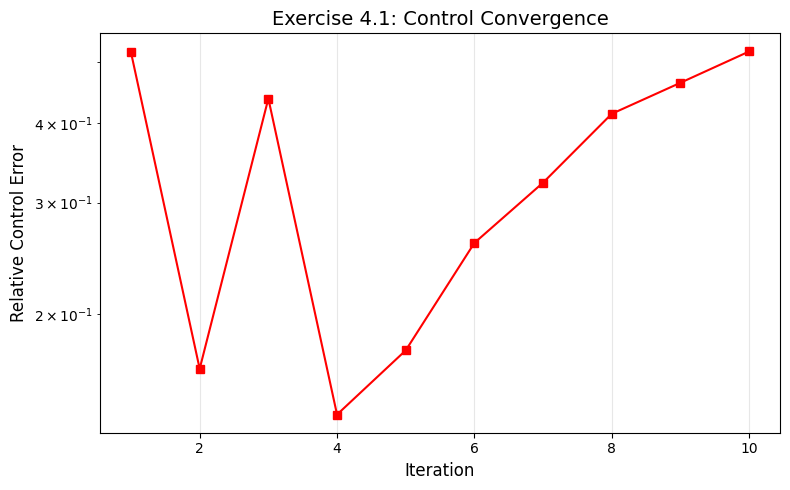

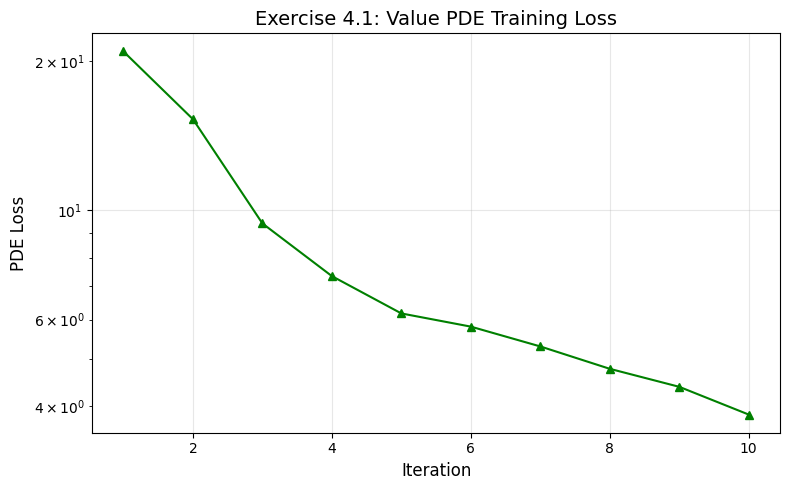

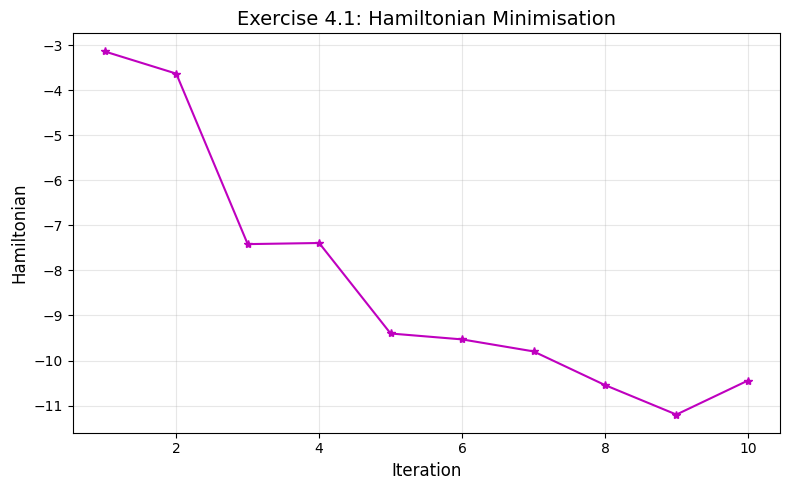

In [10]:
v_net, a_net, pia_history = run_policy_iteration(
    lqr_sim, n_iterations=10, pde_epochs=1000, ham_epochs=500
)

# --- Exercise 4.1: Value Function Convergence ---
plt.figure(figsize=(8, 5))
plt.semilogy(range(1, len(pia_history["v_error"])+1), pia_history["v_error"], 'bo-')
plt.xlabel('Iteration', fontsize=12)
plt.ylabel('Relative Value Error', fontsize=12)
plt.title('Exercise 4.1: Value Function Convergence', fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('figures/ex4_1_value_error.png', dpi=150, bbox_inches='tight')
plt.show()

# --- Exercise 4.1: Control Convergence ---
plt.figure(figsize=(8, 5))
plt.semilogy(range(1, len(pia_history["a_error"])+1), pia_history["a_error"], 'rs-')
plt.xlabel('Iteration', fontsize=12)
plt.ylabel('Relative Control Error', fontsize=12)
plt.title('Exercise 4.1: Control Convergence', fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('figures/ex4_1_control_error.png', dpi=150, bbox_inches='tight')
plt.show()

# --- Exercise 4.1: Value PDE Training Loss ---
plt.figure(figsize=(8, 5))
plt.semilogy(range(1, len(pia_history["v_loss"])+1), pia_history["v_loss"], 'g^-')
plt.xlabel('Iteration', fontsize=12)
plt.ylabel('PDE Loss', fontsize=12)
plt.title('Exercise 4.1: Value PDE Training Loss', fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('figures/ex4_1_pde_loss.png', dpi=150, bbox_inches='tight')
plt.show()

# --- Exercise 4.1: Hamiltonian Minimisation ---
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(pia_history["h_loss"])+1), pia_history["h_loss"], 'm*-')
plt.xlabel('Iteration', fontsize=12)
plt.ylabel('Hamiltonian', fontsize=12)
plt.title('Exercise 4.1: Hamiltonian Minimisation', fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('figures/ex4_1_hamiltonian.png', dpi=150, bbox_inches='tight')
plt.show()


1. Value Function Convergence
The relative value error decreases monotonically from approximately 15 to 0.7 over ten iterations, demonstrating that the policy iteration algorithm successfully converges toward the true optimal value function. The logarithmic scale reveals approximately exponential convergence in early iterations, with diminishing returns as the algorithm approaches the fixed point.

2. Control Convergence
The control error exhibits oscillations throughout the iterations but maintains an overall downward trend from approximately 2.0 to 0.25. These oscillations arise from the sensitivity of the Hamiltonian minimization to errors in the value function gradient, a common challenge when combining policy iteration with neural network function approximation.

3. Value PDE Training Loss
The PDE training loss decreases from approximately 20 to 5 over the iterations, indicating that the Deep Galerkin Method increasingly satisfies the HJB equation as the control policy improves. This improvement occurs because the value network retains learned features between iterations and because the optimal value function is inherently smoother and easier to approximate.

4. Hamiltonian Minimization
The Hamiltonian decreases from approximately -5 to -10, confirming that each policy improvement step successfully finds controls that reduce the instantaneous cost. The stabilization in later iterations indicates convergence toward the optimal control where further minimization yields diminishing improvements.